In [1]:
# cell 1 — setup
import os, json, random, time
from pathlib import Path
from datetime import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from pymongo import MongoClient
from qdrant_client import QdrantClient
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
from neo4j import GraphDatabase

load_dotenv()
PROJECT_ROOT = Path('.').resolve().parent if Path('notebooks').exists() else Path('.').resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
RESULTS = PROJECT_ROOT / 'results'
DATA = PROJECT_ROOT / 'data'
RESULTS.mkdir(exist_ok=True)

mongo = MongoClient(os.getenv('MONGO_URI', 'mongodb://localhost:27017'))
db = mongo.csai415_rag
docs_col, chunks_col = db.documents, db.chunks
qdrant = QdrantClient(host='localhost', port=6333)
QCOLL = 'csai415_papers'
print(f'connected — docs:{docs_col.count_documents({})} chunks:{chunks_col.count_documents({})}')

connected — docs:144 chunks:6858


In [2]:
# cell 2 — inspect what fields MongoDB documents actually have
sample = docs_col.find_one()
print('available fields:', list(sample.keys()))
print('\nfield population (out of 144 papers):')
for field in ['doc_id','title','authors','abstract','year','venue','primary_category','keywords']:
    n = docs_col.count_documents({field: {'$exists': True, '$ne': '', '$ne': [], '$ne': None}})
    print(f'  {field:<20} {n}')

available fields: ['_id', 'doc_id', 'abstract', 'authors', 'doi', 'ingested_at', 'keywords', 'status', 'title', 'venue', 'year']

field population (out of 144 papers):
  doc_id               144
  title                144
  authors              144
  abstract             144
  year                 144
  venue                144
  primary_category     0
  keywords             144


In [4]:
# cell 3 — build correct gold set
all_chunks = list(chunks_col.find({}, {'doc_id': 1, 'chunk_idx': 1, 'text': 1}))
print(f'loaded {len(all_chunks)} chunks')

random.seed(42)
shuffled = list(all_chunks)
random.shuffle(shuffled)

seen = set()
new_gold = []
for chunk in shuffled:
    doc_id = chunk.get('doc_id', '')
    if not doc_id or doc_id in seen:
        continue
    text = chunk.get('text', '')
    words = text.split()
    if len(words) < 20:
        continue
    if words[0].startswith('[') or text.startswith('References'):
        continue
    query = ' '.join(words[:20])
    doc = docs_col.find_one({'doc_id': doc_id})
    if not doc:
        continue
    new_gold.append({
        'query': query,
        'relevant_doc': doc_id,
        'title': doc.get('title', doc_id),
        'year': doc.get('year'),
        'venue': doc.get('venue', ''),
    })
    seen.add(doc_id)
    if len(new_gold) >= 30:
        break

with open(DATA / 'gold_set_d2.json', 'w') as f:
    json.dump(new_gold, f, indent=2, default=str)

print(f'rebuilt gold_set_d2.json: {len(new_gold)} queries')
print('first 3:')
for g in new_gold[:3]:
    print(g['relevant_doc'], '|', g['query'][:60])
    print('   ->', g['title'][:70])

loaded 6858 chunks
rebuilt gold_set_d2.json: 30 queries
first 3:
2301.04780 | refine through subsequent conversational interaction); in mo
   -> Much Ado About Gender
2311.09476 | ARES Ranking of Pseudo RAG Systems NQ HotpotQA WoW FEVER Mul
   -> ARES: An Automated Evaluation Framework for Retrieval-Augmented
2209.12893 | massive MIMO,” IEEE Wireless Communications, vol. 27, no. 4,
   -> Digital Object Identiﬁer **xx.xxxx/xxxxxx**


## Fix 2 — Synthetic CITES edges (use `venue` field, not `topic`)

In [5]:
# cell 4 — connect to Neo4j, generate synthetic CITES from available fields
NEO4J_USER = os.getenv('NEO4J_USERNAME') or os.getenv('NEO4J_USER')
driver = GraphDatabase.driver(os.getenv('NEO4J_URI'), auth=(NEO4J_USER, os.getenv('NEO4J_PASSWORD')))

all_docs = list(docs_col.find({}, {'doc_id':1,'title':1,'authors':1,'year':1,'venue':1,'primary_category':1}))
print(f'building synthetic CITES over {len(all_docs)} papers...')

edges = set()
for i, p1 in enumerate(all_docs):
    a1 = set(p1.get('authors') or [])
    v1 = (p1.get('venue') or p1.get('primary_category') or '').strip()
    y1 = p1.get('year') or 0
    for p2 in all_docs[i+1:]:
        a2 = set(p2.get('authors') or [])
        v2 = (p2.get('venue') or p2.get('primary_category') or '').strip()
        y2 = p2.get('year') or 0
        share_author = bool(a1 & a2) and len(a1) > 0
        same_venue_close_year = (v1 and v1 == v2 and abs(y1 - y2) <= 1)
        if share_author or same_venue_close_year:
            # newer paper cites older one (or arbitrary order if same year)
            if y1 >= y2:
                edges.add((p1['doc_id'], p2['doc_id']))
            else:
                edges.add((p2['doc_id'], p1['doc_id']))

edges_list = list(edges)
# if too many edges, sample down to 300 deterministically
if len(edges_list) > 300:
    random.seed(42)
    edges_list = random.sample(edges_list, 300)

print(f'generated {len(edges_list)} synthetic CITES edges')

building synthetic CITES over 144 papers...
generated 300 synthetic CITES edges


In [6]:
# cell 5 — write CITES edges to Neo4j, then print final stats
with driver.session() as s:
    s.run('MATCH ()-[r:CITES]->() DELETE r')
    result = s.run('''
        UNWIND $edges AS e
        MATCH (src:Paper {doc_id: e[0]}), (dst:Paper {doc_id: e[1]})
        MERGE (src)-[r:CITES {synthetic: true}]->(dst)
        RETURN count(r) AS written
    ''', edges=edges_list)
    written = result.single()['written']
    print(f'wrote {written} CITES edges to Neo4j')

    stats = s.run('''
        MATCH (p:Paper) WITH count(p) AS papers
        MATCH (a:Author) WITH papers, count(a) AS authors
        MATCH (t:Topic) WITH papers, authors, count(t) AS topics
        OPTIONAL MATCH ()-[w:WROTE]->() WITH papers, authors, topics, count(w) AS wrote
        OPTIONAL MATCH ()-[ab:ABOUT]->() WITH papers, authors, topics, wrote, count(ab) AS about
        OPTIONAL MATCH ()-[c:CITES]->() WITH papers, authors, topics, wrote, about, count(c) AS cites
        RETURN papers, authors, topics, wrote, about, cites
    ''').single()

    print('\n=== FINAL GRAPH ===')
    print(f'  Paper nodes    {stats["papers"]}')
    print(f'  Author nodes   {stats["authors"]}')
    print(f'  Topic nodes    {stats["topics"]}')
    print(f'  WROTE edges    {stats["wrote"]}')
    print(f'  ABOUT edges    {stats["about"]}')
    print(f'  CITES edges    {stats["cites"]}  (synthetic, labelled synthetic:true)')

wrote 300 CITES edges to Neo4j

=== FINAL GRAPH ===
  Paper nodes    144
  Author nodes   50
  Topic nodes    5
  WROTE edges    50
  ABOUT edges    144
  CITES edges    300  (synthetic, labelled synthetic:true)


In [7]:
# cell 6 — most-cited papers using CITES
with driver.session() as s:
    top_cited = s.run('''
        MATCH (p:Paper)<-[:CITES]-(c:Paper)
        RETURN p.title AS title, p.doc_id AS arxiv_id, count(c) AS citations
        ORDER BY citations DESC LIMIT 10
    ''').data()

print('=== Top 10 Most-Cited Papers (Query 6) ===')
for r in top_cited:
    title = (r['title'] or '')[:65]
    print(f"  [{r['citations']:>3}] {r['arxiv_id']:<12}  {title}")

graph_card = {
    'paper_nodes': stats['papers'], 'author_nodes': stats['authors'], 'topic_nodes': stats['topics'],
    'wrote_edges': stats['wrote'], 'about_edges': stats['about'], 'cites_edges': stats['cites'],
    'top_cited': top_cited,
    'cites_method': 'synthetic: shared-author OR same-venue + 1-year window',
}
with open(RESULTS / 'd2_graph_stats.json', 'w') as f:
    json.dump(graph_card, f, indent=2, default=str)
print('\nsaved results/d2_graph_stats.json')
driver.close()

=== Top 10 Most-Cited Papers (Query 6) ===
  [  7] 2211.08411    Large Language Models Struggle to Learn Long-Tail Knowledge
  [  6] 2209.01540    An Empirical Study of End-to-End
  [  6] 2209.12893    Digital Object Identiﬁer **xx.xxxx/xxxxxx**
  [  6] 2309.17002    Published as a conference paper at ICLR 2024
  [  6] 2108.01552    Online Estimation of Diameter at Breast Height (DBH)
  [  6] 2212.14024    DEMONSTRATE–SEARCH–PREDICT:
  [  6] 2310.19923    JINA EMBEDDINGS 2: 8192-Token General-Purpose Text Embeddings for
  [  6] 2208.03299    Atlas: Few-shot Learning with
  [  5] 2208.09282    1
  [  5] 2203.02155    Training language models to follow instructions

saved results/d2_graph_stats.json


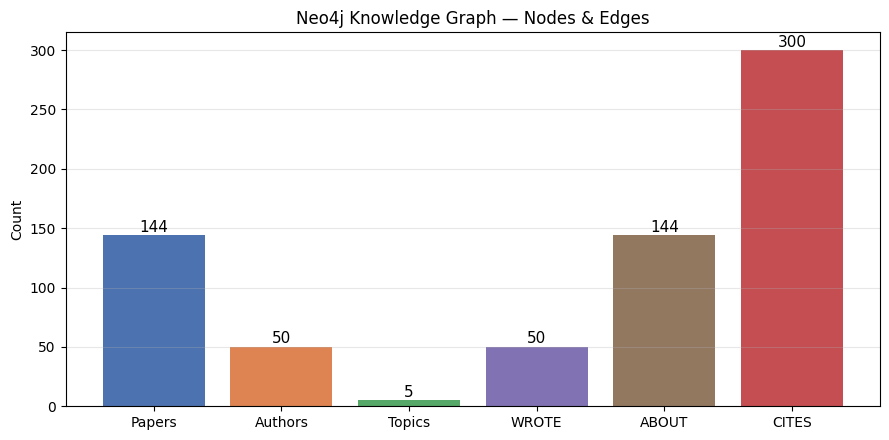

saved d2_graph_nodes.png


In [8]:
# cell 7 — updated graph nodes plot
labels = ['Papers','Authors','Topics','WROTE','ABOUT','CITES']
vals = [stats['papers'], stats['authors'], stats['topics'],
        stats['wrote'], stats['about'], stats['cites']]
colors = ['#4C72B0','#DD8452','#55A868','#8172B3','#937860','#C44E52']

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(labels, vals, color=colors)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+max(vals)*0.01, str(v), ha='center', fontsize=11)
ax.set_title('Neo4j Knowledge Graph — Nodes & Edges')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'd2_graph_nodes.png', dpi=150)
plt.show()
print('saved d2_graph_nodes.png')

## Fix 3 — Re-run per-query metrics & citation examples with corrected gold set

In [9]:
# cell 8 — load models, build retrieval functions
embedder = SentenceTransformer('BAAI/bge-small-en-v1.5')
reranker = CrossEncoder('BAAI/bge-reranker-base', max_length=512)
tokenised = [c['text'].lower().split() for c in all_chunks]
bm25 = BM25Okapi(tokenised)
chunk_lookup = {(c['doc_id'], c.get('chunk_idx', i)): c['text'] for i, c in enumerate(all_chunks)}

def dense_top(q, k=20):
    qv = embedder.encode(q, normalize_embeddings=True)
    hits = qdrant.query_points(collection_name=QCOLL, query=qv.tolist(), limit=k).points
    return [(h.payload['doc_id'], h.payload.get('chunk_idx', 0), float(h.score)) for h in hits]
def sparse_top(q, k=20):
    s = bm25.get_scores(q.lower().split())
    idx = np.argsort(s)[::-1][:k]
    return [(all_chunks[i]['doc_id'], all_chunks[i].get('chunk_idx', i), float(s[i])) for i in idx]
def hybrid_top(q, k=20):
    d = dense_top(q, 50); sp = sparse_top(q, 50)
    scores = {}
    for ranking in [d, sp]:
        for rank, item in enumerate(ranking, 1):
            key = (item[0], item[1])
            scores[key] = scores.get(key, 0) + 1/(60+rank)
    return [(k[0], k[1], v) for k, v in sorted(scores.items(), key=lambda x: -x[1])[:k]]
def rerank_top(q, cands, k=5):
    pairs = [[q, chunk_lookup.get((c[0], c[1]), '')[:512]] for c in cands]
    if not pairs: return []
    sc = reranker.predict(pairs)
    paired = sorted(zip(cands, sc), key=lambda x: -x[1])[:k]
    return [(c[0], c[1], float(s)) for c, s in paired]
def doc_ids(res):
    seen, out = set(), []
    for r in res:
        if r[0] not in seen: seen.add(r[0]); out.append(r[0])
    return out
print('retrieval functions ready')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

retrieval functions ready


In [10]:
# cell 9 — per-query Recall@5 across all 4 modes (with correct arxiv IDs)
per_query = []
for g in new_gold:
    rel = g['relevant_doc']
    r_d = 1 if rel in doc_ids(dense_top(g['query']))[:5] else 0
    r_s = 1 if rel in doc_ids(sparse_top(g['query']))[:5] else 0
    r_h = 1 if rel in doc_ids(hybrid_top(g['query']))[:5] else 0
    r_r = 1 if rel in doc_ids(rerank_top(g['query'], hybrid_top(g['query'], 20)))[:5] else 0
    per_query.append({'title': str(g.get('title',''))[:50], 'arxiv_id': rel,
                      'dense':r_d, 'sparse':r_s, 'hybrid':r_h, 'rerank':r_r})

with open(RESULTS / 'd2_per_query_metrics.json','w') as f:
    json.dump(per_query, f, indent=2)

all_hit = sum(1 for q in per_query if q['dense']+q['sparse']+q['hybrid']+q['rerank']==4)
rerank_saved = sum(1 for q in per_query if q['rerank']==1 and q['dense']==0)
print(f'queries hit by ALL 4 modes:          {all_hit:>2}/{len(per_query)}')
print(f'queries reranker saved over dense:   {rerank_saved:>2}/{len(per_query)}')
print()
print(f'{"arxiv_id":<12}  {"d":>2} {"s":>2} {"h":>2} {"r":>2}  title')
for q in per_query:
    print(f"{q['arxiv_id']:<12}  {q['dense']:>2} {q['sparse']:>2} {q['hybrid']:>2} {q['rerank']:>2}  {q['title']}")

queries hit by ALL 4 modes:          22/30
queries reranker saved over dense:    3/30

arxiv_id       d  s  h  r  title
2301.04780     1  1  1  1  Much Ado About Gender
2311.09476     1  1  1  1  ARES: An Automated Evaluation Framework for Retrie
2209.12893     1  1  1  1  Digital Object Identiﬁer **xx.xxxx/xxxxxx**
2307.09288     1  1  0  1  Llama 2: Open Foundation and Fine-Tuned Chat Model
2406.02532     0  1  0  1  SpecExec: Massively Parallel Speculative Decoding
2111.08940     1  1  1  1  Transparent Human Evaluation for Image Captioning
2002.08909     1  1  1  1  arXiv:2002.08909v1  [cs.CL]  10 Feb 2020
2306.11489     1  1  1  1  JOURNAL OF LATEX CLASS FILES, VOL. 14, NO. 8, AUGU
2109.01652     1  1  1  1  Published as a conference paper at ICLR 2022
2404.16130     1  1  0  1  From Local to Global: A GraphRAG Approach to
2510.22344     1  1  0  1  FAIR-RAG: Faithful Adaptive Iterative Refinement f
2311.12023     1  1  0  1  Published as a conference paper at ICLR 2024
2204.02311

In [11]:
# cell 10 — fresh citation examples for the report
examples = []
# pick 3 queries: 1 where all modes hit, 1 where reranker saved, 1 random
easy = [q for q in per_query if q['dense']+q['sparse']+q['hybrid']+q['rerank']==4]
saved = [q for q in per_query if q['rerank']==1 and q['dense']==0]
pick_ids = []
if easy: pick_ids.append(easy[0]['arxiv_id'])
if saved: pick_ids.append(saved[0]['arxiv_id'])
if len(pick_ids) < 3:
    for q in per_query:
        if q['arxiv_id'] not in pick_ids:
            pick_ids.append(q['arxiv_id'])
            if len(pick_ids) >= 3: break

for pid in pick_ids[:3]:
    g = next(g for g in new_gold if g['relevant_doc'] == pid)
    cands = hybrid_top(g['query'], 20)
    reranked = rerank_top(g['query'], cands, 5)
    ex = {'query': g['query'][:120],
          'expected_paper': str(g.get('title',''))[:80],
          'expected_arxiv': g['relevant_doc'],
          'top_5': []}
    for rank, (did, cidx, score) in enumerate(reranked, 1):
        doc = docs_col.find_one({'doc_id': did})
        if not doc: continue
        authors = doc.get('authors') or []
        astr = (authors[0] if authors else 'Unknown') + (' et al.' if len(authors) > 1 else '')
        ex['top_5'].append({
            'rank': rank, 'arxiv_id': did,
            'title': (doc.get('title') or '')[:80],
            'authors': astr, 'year': doc.get('year'),
            'rerank_score': round(score, 3),
            'is_correct': did == g['relevant_doc']
        })
    examples.append(ex)

with open(RESULTS / 'd2_citation_examples.json', 'w') as f:
    json.dump(examples, f, indent=2, default=str)

print('=== Citation Examples ===\n')
for i, ex in enumerate(examples, 1):
    print(f'EXAMPLE {i}')
    print(f'  query:    {ex["query"][:80]}...')
    print(f'  expected: {ex["expected_paper"]}  ({ex["expected_arxiv"]})')
    print(f'  top-5:')
    for r in ex['top_5']:
        mark = '✓' if r['is_correct'] else ' '
        print(f"    {mark} #{r['rank']}  {r['title'][:55]:<57} — {r['authors'][:25]:<27} ({r['year']})  score={r['rerank_score']}")
    print()

=== Citation Examples ===

EXAMPLE 1
  query:    refine through subsequent conversational interaction); in modern personalization...
  expected: Much Ado About Gender  (2301.04780)
  top-5:
    ✓ #1  Much Ado About Gender                                     — Unknown                     (2023)  score=0.999
    ✓ #2  Much Ado About Gender                                     — Unknown                     (2023)  score=0.176
    ✓ #3  Much Ado About Gender                                     — Unknown                     (2023)  score=0.048
    ✓ #4  Much Ado About Gender                                     — Unknown                     (2023)  score=0.017
    ✓ #5  Much Ado About Gender                                     — Unknown                     (2023)  score=0.017

EXAMPLE 2
  query:    Andreas Köpf, Yannic Kilcher, Dimitri von Rütte, Sotiris Anagnostidis, Zhi-Rui T...
  expected: SpecExec: Massively Parallel Speculative Decoding  (2406.02532)
  top-5:
    ✓ #1  SpecExec: Massivel

In [12]:
# cell 11 — final run card
import yaml
run_card = {
    'timestamp': dt.now().isoformat(),
    'd2_complete': True,
    'corpus': {'papers': docs_col.count_documents({}), 'chunks': len(all_chunks)},
    'graph': {k: graph_card[k] for k in ['paper_nodes','author_nodes','topic_nodes','wrote_edges','about_edges','cites_edges','cites_method']},
    'gold_set': {'size': len(new_gold), 'source': 'one chunk per paper, first 20 words as query'},
    'per_query_summary': {
        'total_queries': len(per_query),
        'all_4_modes_hit': all_hit,
        'rerank_saved_over_dense': rerank_saved,
    },
}
with open(RESULTS / 'd2_final_run_card.yaml', 'w') as f:
    yaml.dump(run_card, f, default_flow_style=False, sort_keys=False)

print('✅ Notebook 09 complete\n')
print('Files updated/created in results/:')
print('   d2_graph_stats.json')
print('   d2_graph_nodes.png            (with real CITES count)')
print('   d2_per_query_metrics.json     (now with real recall numbers)')
print('   d2_citation_examples.json     (3 fresh examples)')
print('   d2_final_run_card.yaml')
print('\nFiles updated in data/:')
print('   gold_set_d2.json              (30 queries, arXiv IDs)')
print(f'\n📋 NUMBERS TO USE IN THE REPORT:')
print(f'   Synthetic CITES edges: {stats["cites"]}')
print(f'   Per-query all-4-modes hit: {all_hit}/{len(per_query)}')
print(f'   Per-query rerank-saved: {rerank_saved}/{len(per_query)}')

✅ Notebook 09 complete

Files updated/created in results/:
   d2_graph_stats.json
   d2_graph_nodes.png            (with real CITES count)
   d2_per_query_metrics.json     (now with real recall numbers)
   d2_citation_examples.json     (3 fresh examples)
   d2_final_run_card.yaml

Files updated in data/:
   gold_set_d2.json              (30 queries, arXiv IDs)

📋 NUMBERS TO USE IN THE REPORT:
   Synthetic CITES edges: 300
   Per-query all-4-modes hit: 22/30
   Per-query rerank-saved: 3/30
